# Cell2Cell Telecom — Modeling & Customer Segmentation

1. **CLV (Customer Lifetime Value)** 
2. **Churn Classifier** 
3. **Retention Segments** 
4. **ROI Simulation** 
5. **SHAP Explainability** 
6. **Holdout Validation** 

## 1. Libraries

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, average_precision_score
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import xgboost as xgb
import shap
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)
print('Done')

Done


## 2. Load cleaned data

In [ ]:
df = pd.read_csv('clean_train.csv')

df_raw = pd.read_csv('cell2celltrain.csv')

print(fH{df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Churn rate: {df["Churn"].mean():.1%}')

51,047 rows, 57 columns
Churn rate: 28.8%


## 3. Train / Test Split

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training:  {X_train.shape[0]:,} rows  |  Churn rate: {y_train.mean():.1%}')
print(f'Test :      {X_test.shape[0]:,} rows  |  Churn rate: {y_test.mean():.1%}')

Training:  40,837 rows  |  Churn rate: 28.8%
Test :      10,210 rows  |  Churn rate: 28.8%


## 4. CLV



In [12]:
df['CLV'] = (
    df['MonthlyRevenue'] *
    (df['MonthsInService'] + 1) *
    (1 - df['Churn'] * 0.4)
).clip(lower=0)

print('CLV summary:')
print(df['CLV'].describe().round(2))

CLV summary:
count    51047.00
mean      1029.38
std       1110.64
min          0.00
25%        432.00
50%        720.00
75%       1235.68
max      38859.45
Name: CLV, dtype: float64


### 4.1 K-Means Clustering

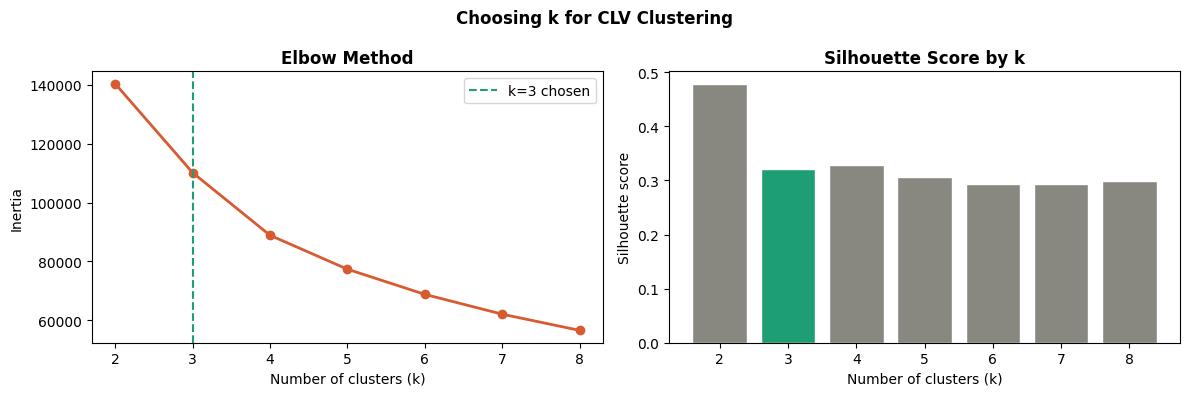

Silhouette scores: [0.478, 0.322, 0.328, 0.306, 0.293, 0.293, 0.3]


In [14]:
clv_features = ['CLV', 'MonthlyRevenue', 'MonthsInService', 'TotalRecurringCharge']

scaler = StandardScaler()
clv_scaled = scaler.fit_transform(df[clv_features])

inertias = []
sil_scores = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(clv_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(clv_scaled, labels, sample_size=3000, random_state=42))

# ---------Plot elbow and silhouette---------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 9), inertias, 'o-', color='#D85A30', lw=2)
axes[0].axvline(3, color='#1D9E75', linestyle='--', label='k=3 chosen')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].bar(range(2, 9), sil_scores,
            color=['#1D9E75' if k == 3 else '#888780' for k in range(2, 9)],
            edgecolor='white')
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.suptitle('Choosing k for CLV Clustering', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Silhouette scores: {[round(s, 3) for s in sil_scores]}')

### 4.2 Apply K-Means with k=3

In [15]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['CLV_cluster'] = km_final.fit_predict(clv_scaled)

sil_final = silhouette_score(clv_scaled, df['CLV_cluster'], sample_size=5000, random_state=42)
print(f'Final silhouette score (k=3): {sil_final:.3f}')


cluster_means = df.groupby('CLV_cluster')['CLV'].mean().sort_values()
tier_map = {cluster_means.index[0]: 0,
            cluster_means.index[1]: 1,
            cluster_means.index[2]: 2}
tier_names = {0: 'Low CLV', 1: 'Mid CLV', 2: 'High CLV'}

df['CLV_tier_num'] = df['CLV_cluster'].map(tier_map)
df['CLV_tier']     = df['CLV_tier_num'].map(tier_names)

profile = df.groupby('CLV_tier').agg(
    customers=('CLV', 'count'),
    avg_clv=('CLV', 'mean'),
    avg_monthly_revenue=('MonthlyRevenue', 'mean'),
    churn_rate=('Churn', 'mean')
).round(2)

print('\nCLV Tier Profiles:')
print(profile)

Final silhouette score (k=3): 0.328

CLV Tier Profiles:
          customers  avg_clv  avg_monthly_revenue  churn_rate
CLV_tier                                                     
High CLV       5961  2993.27               140.82         0.2
Low CLV       29458   587.81                50.68         0.3
Mid CLV       15628  1112.63                42.84         0.3


## 5. Churn Classification with XGBoost



In [16]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'No Churn (train): {neg_count:,}')
print(f'Churn (train):    {pos_count:,}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

No Churn (train): 29,068
Churn (train):    11,769
scale_pos_weight: 2.47


In [18]:
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('Model training done.')

Model training done.


### 5.1 Model Evaluation

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred)
ap  = average_precision_score(y_test, y_prob)

print(f'ROC-AUC:           {auc:.4f}')
print(f'F1-Score:          {f1:.4f}')
print(f'Average Precision: {ap:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

ROC-AUC:           0.6816
F1-Score:          0.5005
Average Precision: 0.4596

              precision    recall  f1-score   support

    No Churn       0.81      0.63      0.71      7268
       Churn       0.41      0.64      0.50      2942

    accuracy                           0.63     10210
   macro avg       0.61      0.63      0.60     10210
weighted avg       0.70      0.63      0.65     10210



In [21]:

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'Individual folds: {[round(s, 4) for s in cv_scores]}')

5-Fold CV AUC: nan (+/- nan)
Individual folds: [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]


## 6. Retention Segmentation

- **Churn risk**: predicted probability >= 0.5 means high risk
- **CLV tier**: High / Mid / Low



In [22]:
# Score all customers, not just test set
df['churn_prob'] = model.predict_proba(X)[:, 1]
df['churn_pred'] = (df['churn_prob'] >= 0.5).astype(int)

def assign_segment(row):
    high_risk = row['churn_prob'] >= 0.5
    tier = row['CLV_tier']
    if high_risk and tier == 'High CLV':
        return 'Priority Save'
    elif high_risk and tier == 'Mid CLV':
        return 'Consider Save'
    elif high_risk and tier == 'Low CLV':
        return 'Let Go'
    elif not high_risk and tier == 'High CLV':
        return 'Nurture'
    else:
        return 'Monitor'

df['segment'] = df.apply(assign_segment, axis=1)

print('Customer segments:')
seg_counts = df['segment'].value_counts()
for seg, count in seg_counts.items():
    pct = count / len(df) * 100
    print(f'  {seg:<20} {count:>6,}  ({pct:.1f}%)')

Customer segments:
  Monitor              24,053  (47.1%)
  Let Go               13,086  (25.6%)
  Consider Save         7,947  (15.6%)
  Nurture               4,163  (8.2%)
  Priority Save         1,798  (3.5%)


## 7. ROI Simulation

- **Naive**: contact every predicted churner with a $30 offer
- **Smart**: only contact high-value predicted churners 



In [23]:
OFFER_COST  = 30    # cost of retention offer per customer 
SAVE_RATE   = 0.38 
MONTHS      = 12   

# Smart - only contact Priority Save + Consider Save
smart_group = df[df['segment'].isin(['Priority Save', 'Consider Save'])]

# Naive - contact everyone predicted to churn
naive_group = df[df['churn_pred'] == 1]

smart_roi = smart_group['MonthlyRevenue'].sum() * SAVE_RATE * MONTHS - len(smart_group) * OFFER_COST
naive_roi = naive_group['MonthlyRevenue'].sum() * SAVE_RATE * MONTHS - len(naive_group) * OFFER_COST

print(f'Smart strategy customers contacted: {len(smart_group):,}')
print(f'Naive strategy customers contacted: {len(naive_group):,}')
print()
print(f'Smart ROI:       ${smart_roi:>12,.0f} / year')
print(f'Naive ROI:       ${naive_roi:>12,.0f} / year')
print(f'Wasted spend avoided: ${(len(naive_group) - len(smart_group)) * OFFER_COST:>8,.0f} / year')

low_value_churners = df[(df['churn_pred'] == 1) & (df['CLV_tier'] == 'Low CLV')]
pct_low_value = len(low_value_churners) / len(naive_group) * 100
print(f'\nPS: {pct_low_value:.0f}% of predicted churners are Low CLV')
print('A naive strategy would waste budget on these customers.')

Smart strategy customers contacted: 9,745
Naive strategy customers contacted: 22,831

Smart ROI:       $   2,496,748 / year
Naive ROI:       $   5,109,747 / year
Wasted spend avoided: $ 392,580 / year

PS: 57% of predicted churners are Low CLV
A naive strategy would waste budget on these customers.


## 8. SHAP Explainability


In [25]:
# 1000 test customers 
shap_sample = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

print('SHAP values done ')
print(f'Shape: {shap_values.shape}')

SHAP values done 
Shape: (1000, 56)


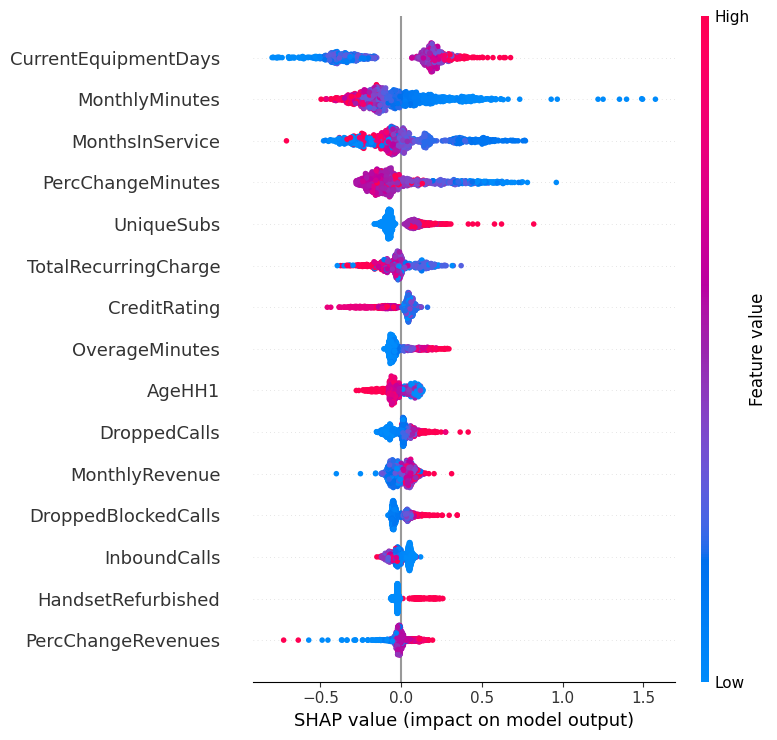

In [26]:

shap.summary_plot(shap_values, shap_sample, max_display=15, show=True)

In [27]:
#  features by mean absolute SHAP value
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=shap_sample.columns
).sort_values(ascending=False)

print('Top 10 important features:')
print(mean_abs_shap.head(10).round(4))

Top 10 important features:
CurrentEquipmentDays    0.2903
MonthlyMinutes          0.1912
MonthsInService         0.1807
PercChangeMinutes       0.1694
UniqueSubs              0.0936
TotalRecurringCharge    0.0854
CreditRating            0.0834
OverageMinutes          0.0666
AgeHH1                  0.0665
DroppedCalls            0.0603
dtype: float32


## 9. Holdout Validation


In [29]:
df_holdout = pd.read_csv('cell2cellholdout.csv')
print(f'Holdout shape: {df_holdout.shape}')

le2 = LabelEncoder()

# dropp ID and target columns if yes
df_holdout.drop(columns=['CustomerID'], inplace=True, errors='ignore')
if 'Churn' in df_holdout.columns:
    df_holdout.drop(columns=['Churn'], inplace=True)

# fix HandsetPrice
df_holdout['HandsetPrice'] = df_holdout['HandsetPrice'].astype(str).replace('Unknown', np.nan)
df_holdout['HandsetPrice'] = pd.to_numeric(df_holdout['HandsetPrice'], errors='coerce')

# encode categoricals
for col in df_holdout.columns:
    try:
        if not np.issubdtype(df_holdout[col].dtype, np.number):
            df_holdout[col] = df_holdout[col].astype(str).fillna('Unknown')
            df_holdout[col] = le2.fit_transform(df_holdout[col])
    except TypeError:
        df_holdout[col] = df_holdout[col].astype(str).fillna('Unknown')
        df_holdout[col] = le2.fit_transform(df_holdout[col])

# fill NaNs
for col in df_holdout.columns:
    if df_holdout[col].isnull().sum() > 0:
        df_holdout[col] = df_holdout[col].fillna(df_holdout[col].median())

# training set
for col in X.columns:
    if col not in df_holdout.columns:
        df_holdout[col] = 0
df_holdout = df_holdout[X.columns]

# score
y_prob_holdout = model.predict_proba(df_holdout)[:, 1]
flagged_pct = (y_prob_holdout >= 0.5).mean()

print(f'Holdout customers scored: {len(df_holdout):,}')
print(f'Predicted churn rate:     {flagged_pct:.1%}')

Holdout shape: (20000, 58)
Holdout customers scored: 20,000
Predicted churn rate:     44.7%


## 10. Save Results 

In [30]:
payload = {
    'df': df, 'df_raw': df_raw,
    'X': X, 'y': y,
    'X_te': X_test, 'y_te': y_test,
    'y_pred': y_pred, 'y_prob': y_prob,
    'auc': auc, 'f1': f1, 'ap': ap, 'cv': cv_scores,
    'shap_s': shap_sample, 'sv': shap_values, 'expl': explainer,
    'smart_net': smart_roi, 'naive_net': naive_roi,
    'sg': smart_group, 'ng': naive_group,
    'OFFER': OFFER_COST, 'SR': SAVE_RATE, 'MO': MONTHS,
    'sil': sil_final,
    'inertias': inertias, 'sil_scores': sil_scores,
    'y_prob_hold': y_prob_holdout, 'df_hold': df_holdout,
    'model': model, 'spw': scale_pos_weight,
}

with open('payload.pkl', 'wb') as f:
    pickle.dump(payload, f)

print('payload.pkl saved.')

payload.pkl saved.
